# 1. Data Analysis

## This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.


Load `air_fryers_clean_brand_year.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


1. Verify that the data contain 10 brands and the years 2019-2023.

In [130]:
print('there are', df['brand'].nunique(), 'brands which are', df['brand'].unique())

there are 10 brands which are ['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']


In [4]:
print('the years range from', df['year'].min(), 'to', df['year'].max())

the years range from 2019 to 2023


2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share

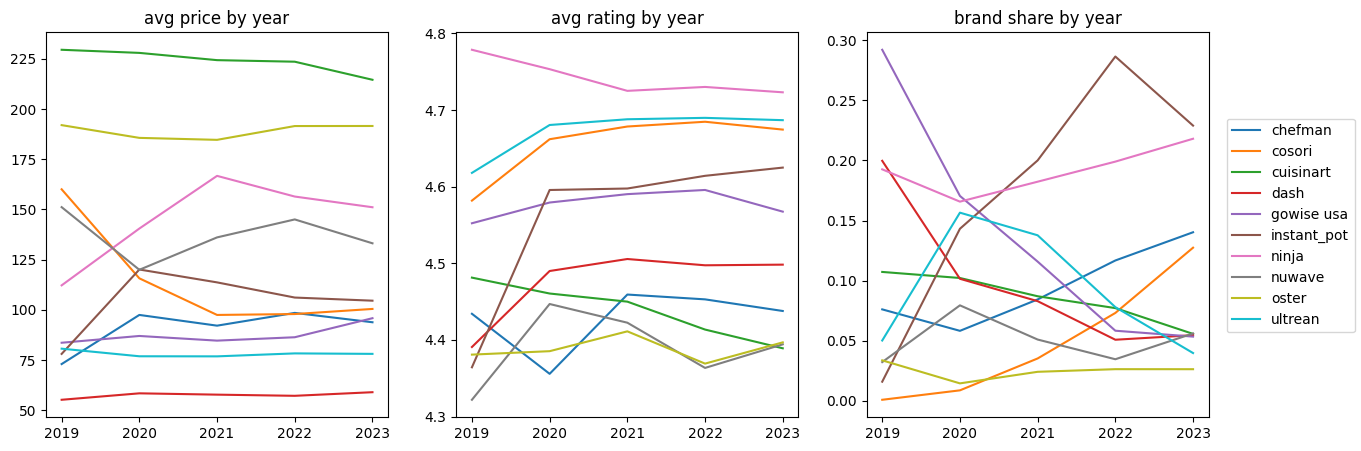

In [22]:
fig, axs = plt.subplots(1, 3, sharex=True, figsize=(15, 5))

y_vars = ['avg_price', 'avg_rating', 'brand_share']
for i in [0, 1, 2]:
    for brand in df['brand'].unique():
        one_brand = df[df['brand'] == brand]
        if i == 0: axs[i].plot(one_brand['year'], one_brand[y_vars[i]], label=brand)
        else: axs[i].plot(one_brand['year'], one_brand[y_vars[i]])
    axs[i].set_title(y_vars[i].replace('_', ' ') + ' by year')

fig.legend(loc='outside right')
plt.show()

3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?

In [50]:
compact_shares = []
dual_basket_shares = []
oven_style_shares = []
rotisserie_shares = []
window_shares = []

features = [('compact_share', compact_shares), 
            ('dual_basket_share', dual_basket_shares),
            ('oven_style_share', oven_style_shares),
            ('rotisserie_share', rotisserie_shares),
            ('window_share', window_shares)]

In [51]:
for feature, list_for_feature in features:
    for year in df['year'].unique():
        shares = []
        for brand in df['brand'].unique():
            df_row = df.query('brand == "' + brand + '" & year == ' + year.astype(str))
            shares.append(df_row[feature] * df_row['brand_share'])
        list_for_feature.append(np.array(shares).sum())


In [54]:
features_by_year = pd.DataFrame({
    'year': df['year'].unique(),
    'compact_share': compact_shares,
    'dual_basket_share': dual_basket_shares,
    'oven_style_share': oven_style_shares,
    'rotisserie_share': rotisserie_shares,
    'window_share': window_shares
})
features_by_year

,year,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
0,2019,0.990780,0.000000,0.481560,0.059698,0.013996
1,2020,0.985837,0.000000,0.505959,0.078802,0.018685
2,2021,0.990081,0.000648,0.550276,0.076532,0.030632
3,2022,0.978453,0.006320,0.555862,0.092212,0.058110
4,2023,0.960000,0.005357,0.505000,0.098333,0.067262


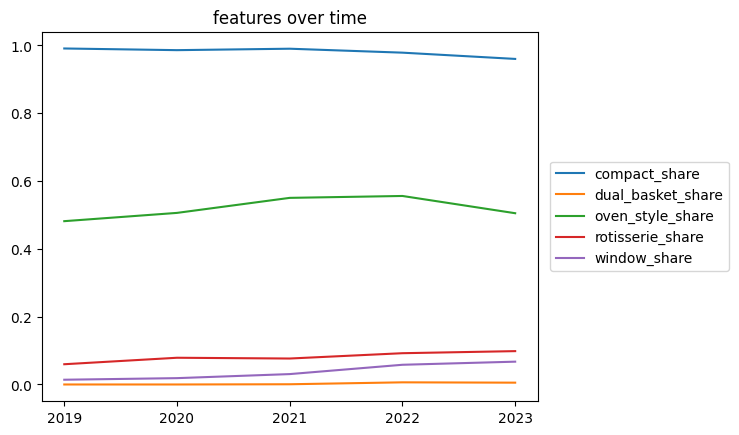

In [96]:
for feature, _ in features:
    plt.plot(features_by_year['year'], features_by_year[feature], label=feature)
plt.xticks(df['year'].unique())
plt.title('features over time')
plt.legend(loc='center right', bbox_to_anchor=(1.4,0.5))
plt.show()

In [131]:
features_summary = pd.DataFrame({
    'feature': [feature for feature, _ in features],
    'min': [features_by_year[feature].min() for feature, _ in features],
    'mean': [features_by_year[feature].mean() for feature, _ in features],
    'max': [features_by_year[feature].max() for feature, _ in features]
})
features_summary.sort_values('mean', axis=0, ascending=False)

,feature,min,mean,max
0,compact_share,0.960000,0.981030,0.990780
2,oven_style_share,0.481560,0.519731,0.555862
3,rotisserie_share,0.059698,0.081115,0.098333
4,window_share,0.013996,0.037737,0.067262
1,dual_basket_share,0.000000,0.002465,0.006320


In [ ]:
features_by_brand = pd.DataFrame({
    'compact_share': df.groupby('brand')['compact_share'].mean(),
    'dual_basket_share': df.groupby('brand')['dual_basket_share'].mean(),
    'oven_style_share': df.groupby('brand')['oven_style_share'].mean(),
    'rotisserie_share': df.groupby('brand')['rotisserie_share'].mean(),
    'window_share': df.groupby('brand')['window_share'].mean(),
})
features_by_brand

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


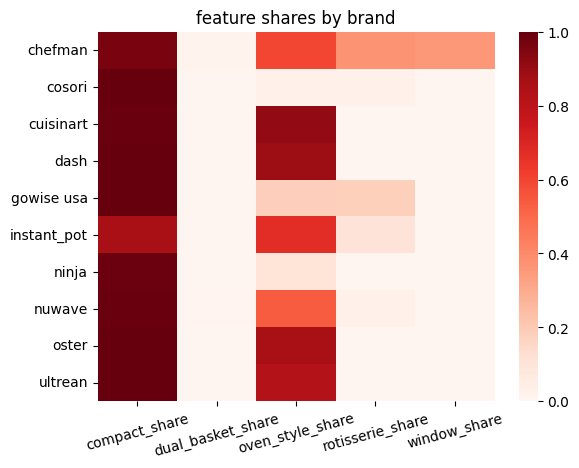

In [119]:
sns.heatmap(features_by_brand, cmap='Reds')
plt.title('feature shares by brand')
plt.ylabel('')
plt.xticks(rotation=15)
plt.show()

Compact-ness is the most common feature of an air fryer. From 2019 to 2023, it was a feature of 96% or more air fryers, averaging 98% across all five years. Dual baskets are the least common feature, appearing in virtually no air fryers across all years. A little over half of the air fryers were oven-style. And, air fryers with rotisserie and window features were less common, making up only about 8% and 3% of the market across the years.

Chefman, Nuwave, and Instant Pot mainly make compact air fryers that sometimes have other features (most often, being oven-style). Cosori and Ninja mainly focus on compactness alone; while Cuisinart, Dash, Oster, and Ultrean seem to specialize in compact, oven-style air fryers. Additionally, Gowise USA mainly features compact-ness, with some dabbling in oven-style and rotisserie fryers.


4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

The most consistently expensive brands are Cusinart and Oster. More recently, Ninja and Nuwave have also become among the more expensive brands. Instant Pot, Ninja, and Chefman have the three largest market shares as of 2023, but the market does not look stable over time. Instant Pot soared to become the most popular, but decreased from about 29% in 2022 to about 23% in 2023. Meanwhile, Ultrean peaked at about 16% market share in 2020, before continually dropping until reaching about 4% market share in 2023. Nonetheless, the average prices and average ratings by brand were relatively stable over time.